In [35]:
import sys
import os
import akshare as ak
from datetime import date, datetime
# 获取当前文件所在目录（B 文件夹），再上移一级变成 project/
current_dir = os.path.dirname(os.path.abspath("__file__"))
project_root = os.path.abspath(os.path.join(current_dir, '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from DataFetch.stock_basic import *
import pandas as pd
from sqlalchemy import create_engine
from common.utils import get_engine, code_add_suffix
import time
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt
import seaborn as sns
# 设置全局中文字体为 SimHei（黑体，常见于 Windows/Linux）
# Songti SC / 
plt.rcParams['font.family'] = 'Kaiti SC'

# 避免负号显示为方块
plt.rcParams['axes.unicode_minus'] = False

In [7]:
engine = get_engine()

In [31]:
query = f"""
SELECT * FROM daily_kline
WHERE trade_date = '2025-05-29'
"""
df = pd.read_sql(query, engine)
print(df.head())

     ts_code  trade_date   open   high    low  close  pre_close  change  \
0  000001.SZ  2025-05-29  11.52  11.55  11.45  11.46      11.53   -0.07   
1  000002.SZ  2025-05-29   6.67   6.73   6.67   6.70       6.68    0.02   
2  000004.SZ  2025-05-29  10.10  10.36   9.81   9.89       9.94   -0.05   
3  000006.SZ  2025-05-29   7.04   7.10   6.96   6.99       7.07   -0.08   
4  000007.SZ  2025-05-29   7.67   7.85   7.63   7.83       7.71    0.12   

   pct_chg       vol     amount  
0  -0.6071  919807.0  1056730.0  
1   0.2994  463601.0   310716.0  
2  -0.5030   95801.0    96535.2  
3  -1.1315  365031.0   255939.0  
4   1.5564   53225.1    41364.4  


In [9]:
df.shape

(5386, 11)

# 涨跌分布

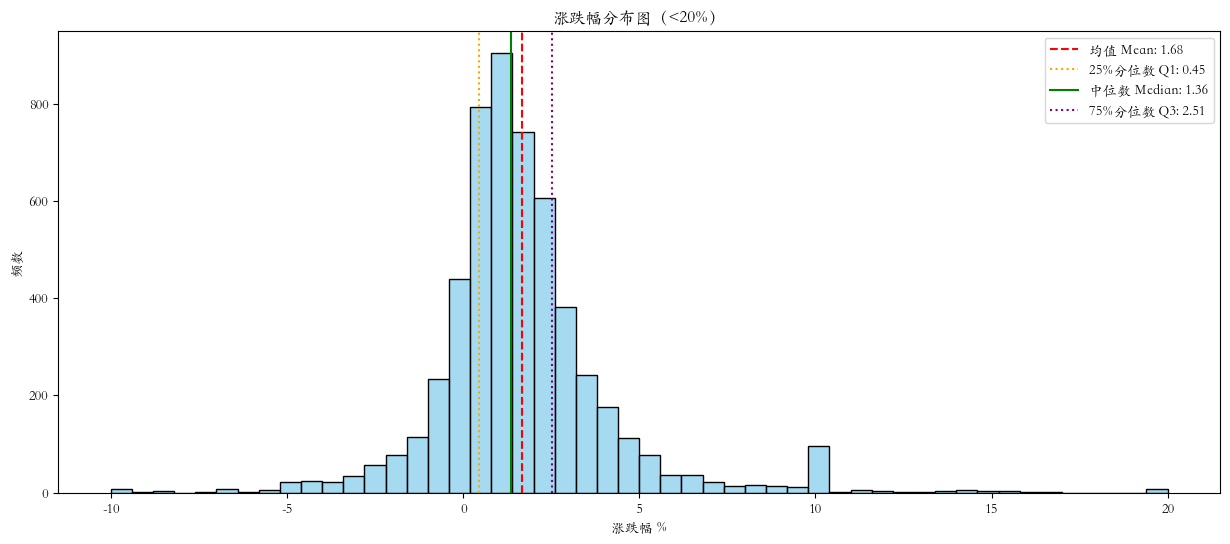

In [42]:
data = df[df.pct_chg < 20]['pct_chg']

# 计算统计量
mean_val = data.mean()
median_val = data.median()
q25 = data.quantile(0.25)
q75 = data.quantile(0.75)

# 设置画布大小
plt.figure(figsize=(15, 6))

# 绘制直方图 + KDE 曲线
sns.histplot(data, kde=False, bins=50, color='skyblue')

# 添加垂直线表示统计值
plt.axvline(mean_val, color='red', linestyle='--', label=f'均值 Mean: {mean_val:.2f}')
plt.axvline(q25, color='orange', linestyle=':', label=f'25%分位数 Q1: {q25:.2f}')
plt.axvline(median_val, color='green', linestyle='-', label=f'中位数 Median: {median_val:.2f}')
plt.axvline(q75, color='purple', linestyle=':', label=f'75%分位数 Q3: {q75:.2f}')

# 添加图例和标签
plt.title('涨跌幅分布图（<20%）')
plt.xlabel('涨跌幅 %')
plt.ylabel('频数')
plt.legend()

# 展示图像
plt.show()

In [19]:
df[df.pct_chg >= 20]

,ts_code,trade_date,open,high,low,close,pre_close,change,pct_chg,vol,amount
508,001390.SZ,2025-05-29,30.00,39.00,29.01,32.00,12.08,19.92,164.9010,391031.0,1278980.0
1613,300149.SZ,2025-05-29,7.12,8.56,7.06,8.56,7.13,1.43,20.0561,664625.0,540923.0
1632,300169.SZ,2025-05-29,6.88,8.26,6.84,8.26,6.88,1.38,20.0581,988396.0,778067.0
1664,300204.SZ,2025-05-29,19.50,23.04,19.20,23.04,19.20,3.84,20.0000,547952.0,1205260.0
1981,300546.SZ,2025-05-29,18.20,22.08,17.91,22.08,18.40,3.68,20.0000,575506.0,1190940.0
2195,300773.SZ,2025-05-29,19.79,23.75,19.51,23.75,19.79,3.96,20.0101,1684660.0,3683870.0
2217,300796.SZ,2025-05-29,9.40,11.51,9.31,11.51,9.59,1.92,20.0209,627013.0,670123.0
2224,300804.SZ,2025-05-29,32.00,41.26,32.00,41.26,34.38,6.88,20.0116,114264.0,415161.0
2436,301024.SZ,2025-05-29,32.00,37.97,31.85,37.97,31.64,6.33,20.0063,47939.0,171926.0
2499,301095.SZ,2025-05-29,52.33,56.74,52.33,56.74,47.28,9.46,20.0085,182976.0,1003220.0
